# Prepare HWSD2 Soil Inputs For SCEPTER

This notebook prepares first-pass soil inputs from the FAO HWSD2 raster for the project AOI.

The HWSD2 raster is a global soil mapping-unit ID raster. It can tell us which soil units intersect the AOI. To generate SCEPTER-ready soil properties such as pH, CEC, clay, and bulk density, the raster must be paired with the HWSD2 attribute table/database.

## Workflow

1. Locate the project and data folder in local or Colab/Drive mode.
2. Locate the HWSD2 raster and MDB from `data/raw/soilgrids/` in the Drive-backed project data folder.
3. Clip the global HWSD2 mapping-unit raster to the AOI.
4. Summarize the soil-unit IDs and pixel shares inside the AOI.
5. If an HWSD2 attribute table exists, join soil properties and write SCEPTER-ready soil defaults.

In [1]:
from pathlib import Path
import os
import sys

try:
    from google.colab import drive

    drive.mount("/content/drive")
except ModuleNotFoundError:
    pass

LOCAL_PROJECT_ROOT = Path.cwd().resolve()
COLAB_PROJECT_ROOT = Path("/content/drive/MyDrive/erw_spatial_mrv")
COLAB_DATA_ROOT = COLAB_PROJECT_ROOT / "data"


def find_project_root(start: Path) -> Path:
    candidates = [LOCAL_PROJECT_ROOT, COLAB_PROJECT_ROOT]
    candidates.extend(start.resolve().parents)
    for candidate in candidates:
        if (candidate / "src" / "erw_mrv").exists():
            return candidate
    raise ModuleNotFoundError(
        "Could not find src/erw_mrv. In Colab, mount Google Drive and confirm "
        "the project is available at /content/drive/MyDrive/erw_spatial_mrv. "
        "Locally, run this notebook from the erw_spatial_mrv project."
    )


SOURCE_PROJECT_ROOT = find_project_root(LOCAL_PROJECT_ROOT)
PROJECT_ROOT = COLAB_PROJECT_ROOT if COLAB_DATA_ROOT.exists() else SOURCE_PROJECT_ROOT
DATA_ROOT = COLAB_DATA_ROOT if COLAB_DATA_ROOT.exists() else PROJECT_ROOT / "data"
os.environ["ERW_MRV_DATA_ROOT"] = str(DATA_ROOT)

SRC = SOURCE_PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"SOURCE_PROJECT_ROOT = {SOURCE_PROJECT_ROOT}")
print(f"DATA_ROOT = {DATA_ROOT}")

PROJECT_ROOT = /Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv
SOURCE_PROJECT_ROOT = /Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv
DATA_ROOT = /Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data


In [2]:
import shutil
import sqlite3
import subprocess
import zipfile

import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
from rasterio.features import shapes
from rasterio.mask import mask
from rasterio.warp import Resampling, reproject
from shapely.geometry import shape

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    plt = None


## Configuration

In [3]:
AOI_PATH = DATA_ROOT / "processed" / "boundaries" / "selected_districts_aoi.geojson"

HWSD_SOIL_DIR = DATA_ROOT / "raw" / "soilgrids"
FALLBACK_HWSD_SOILGRIDS_DIR = DATA_ROOT / "soilgrids"
FALLBACK_HWSD_SOIL_DIR = DATA_ROOT / "soil"
LEGACY_HWSD_RAW_DIR = DATA_ROOT / "raw" / "soil" / "hwsd2"
LOCAL_DOWNLOAD_HWSD_DIR = Path.home() / "Downloads" / "HWSD2_RASTER"

SOIL_PROCESSED_DIR = DATA_ROOT / "processed" / "soil" / "hwsd2"
SOIL_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

AOI_HWSD_RASTER = SOIL_PROCESSED_DIR / "hwsd2_aoi_mapping_units.tif"
AOI_HWSD_UNITS_CSV = SOIL_PROCESSED_DIR / "hwsd2_aoi_mapping_units.csv"
AOI_SOIL_PROPERTIES_CSV = SOIL_PROCESSED_DIR / "hwsd2_aoi_soil_properties.csv"
AOI_SOIL_TYPES_GPKG = SOIL_PROCESSED_DIR / "hwsd2_aoi_soil_types.gpkg"
AOI_SOIL_TYPES_GEOJSON = SOIL_PROCESSED_DIR / "hwsd2_aoi_soil_types.geojson"
SCEPTER_SOIL_DEFAULTS_CSV = SOIL_PROCESSED_DIR / "scepter_soil_defaults_hwsd2.csv"
AOI_HWSD_SOIL_MAP_PNG = SOIL_PROCESSED_DIR / "hwsd2_aoi_soil_texture_map.png"
AOI_HWSD_CROPLAND_OVERLAY_MAP_PNG = SOIL_PROCESSED_DIR / "hwsd2_aoi_soil_texture_cropland_overlay_map.png"
AOI_HWSD_MAP_PNG = AOI_HWSD_CROPLAND_OVERLAY_MAP_PNG
CROPLAND_OVERLAY_CANDIDATES = [
    SOURCE_PROJECT_ROOT.parent / "erw_cdr_ugagric" / "data" / "processed" / "landuse_landcover" / "ug_agric_21landuse.tif",
    DATA_ROOT / "processed" / "landcover" / "cropland_candidate_april_2026.tif",
]
CROPLAND_OVERLAY_RASTER = next((path for path in CROPLAND_OVERLAY_CANDIDATES if path.exists()), None)

if not AOI_PATH.exists():
    raise FileNotFoundError(f"AOI not found: {AOI_PATH}. Run notebook 01 first.")

print(f"HWSD source folder expected in project data: {HWSD_SOIL_DIR}")
print(f"Fallback soilgrids source folder: {FALLBACK_HWSD_SOILGRIDS_DIR}")
print(f"Fallback source folder: {FALLBACK_HWSD_SOIL_DIR}")
print(f"Legacy raw-folder fallback: {LEGACY_HWSD_RAW_DIR}")
print(f"Local Downloads fallback: {LOCAL_DOWNLOAD_HWSD_DIR}")
print(f"Cropland overlay raster: {CROPLAND_OVERLAY_RASTER}")


HWSD source folder expected in project data: /Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/raw/soilgrids
Fallback soilgrids source folder: /Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/soilgrids
Fallback source folder: /Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/soil
Legacy raw-folder fallback: /Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/raw/soil/hwsd2
Local Downloads fallback: /Users/paullwanga/Downloads/HWSD2_RASTER
Cropland overlay raster: /Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_cdr_ugagric/data/processed/landuse_landcover/ug_agric_21landuse.tif


## Locate HWSD2 Raster And Attribute Table

In [4]:
def first_existing(paths):
    for path in paths:
        if path.exists():
            return path
    return None


def recursive_candidates(folder: Path, pattern: str) -> list[Path]:
    return list(folder.glob(f"**/{pattern}")) if folder.exists() else []


def extract_hwsd_raster_from_zip(path: Path) -> Path:
    extract_dir = HWSD_SOIL_DIR / "extracted_raster"
    extract_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(path) as zf:
        members = [name for name in zf.namelist() if Path(name).name.lower() in {"hwsd2.bil", "hwsd2.hdr", "hwsd2.prj", "hwsd2.stx"}]
        if not any(Path(name).name.lower() == "hwsd2.bil" for name in members):
            raise ValueError(f"No HWSD2.bil file found inside {path}")
        for member in members:
            target = extract_dir / Path(member).name
            if not target.exists():
                with zf.open(member) as src, target.open("wb") as dst:
                    shutil.copyfileobj(src, dst)
    return extract_dir / "HWSD2.bil"


def zip_contains_hwsd_raster(path: Path) -> bool:
    try:
        with zipfile.ZipFile(path) as zf:
            return any(Path(name).name.lower() == "hwsd2.bil" for name in zf.namelist())
    except zipfile.BadZipFile:
        return False


def find_hwsd_raster_zip() -> Path | None:
    zip_candidates = [
        HWSD_SOIL_DIR / "HWSD2_RASTER.zip",
        *recursive_candidates(HWSD_SOIL_DIR, "*.zip"),
        FALLBACK_HWSD_SOILGRIDS_DIR / "HWSD2_RASTER.zip",
        *recursive_candidates(FALLBACK_HWSD_SOILGRIDS_DIR, "*.zip"),
        FALLBACK_HWSD_SOIL_DIR / "HWSD2_RASTER.zip",
        *recursive_candidates(FALLBACK_HWSD_SOIL_DIR, "*.zip"),
        Path.home() / "Downloads" / "HWSD2_RASTER.zip",
        *recursive_candidates(Path.home() / "Downloads", "*.zip"),
    ]
    unique_candidates = []
    for candidate in zip_candidates:
        if candidate.exists() and candidate not in unique_candidates:
            unique_candidates.append(candidate)

    for candidate in sorted(unique_candidates, key=lambda path: ("raster" not in path.name.lower(), path.name.lower())):
        if zip_contains_hwsd_raster(candidate):
            return candidate
    return None


def find_hwsd_raster() -> Path | None:
    raster = first_existing([
        HWSD_SOIL_DIR / "HWSD2.bil",
        HWSD_SOIL_DIR / "HWSD2_RASTER" / "HWSD2.bil",
        HWSD_SOIL_DIR / "extracted_raster" / "HWSD2.bil",
        FALLBACK_HWSD_SOILGRIDS_DIR / "HWSD2.bil",
        FALLBACK_HWSD_SOILGRIDS_DIR / "HWSD2_RASTER" / "HWSD2.bil",
        FALLBACK_HWSD_SOILGRIDS_DIR / "extracted_raster" / "HWSD2.bil",
        FALLBACK_HWSD_SOIL_DIR / "HWSD2.bil",
        FALLBACK_HWSD_SOIL_DIR / "HWSD2_RASTER" / "HWSD2.bil",
        FALLBACK_HWSD_SOIL_DIR / "extracted_raster" / "HWSD2.bil",
        LEGACY_HWSD_RAW_DIR / "HWSD2.bil",
        LOCAL_DOWNLOAD_HWSD_DIR / "HWSD2.bil",
        *recursive_candidates(HWSD_SOIL_DIR, "HWSD2.bil"),
        *recursive_candidates(FALLBACK_HWSD_SOILGRIDS_DIR, "HWSD2.bil"),
        *recursive_candidates(FALLBACK_HWSD_SOIL_DIR, "HWSD2.bil"),
    ])
    if raster is not None:
        return raster

    raster_zip = find_hwsd_raster_zip()
    if raster_zip is not None:
        print(f"Extracting HWSD2 raster zip: {raster_zip}")
        return extract_hwsd_raster_from_zip(raster_zip)
    return None


hwsd_raster = find_hwsd_raster()

if hwsd_raster is None:
    raise FileNotFoundError(
        "Could not find HWSD2.bil. Put the FAO HWSD2 raster files in "
        f"{HWSD_SOIL_DIR}, or put the HWSD2 raster zip there. In Colab this is "
        "/content/drive/MyDrive/erw_spatial_mrv/data/raw/soilgrids."
    )

attribute_candidates = []
attribute_candidates.extend(SOIL_PROCESSED_DIR.glob("hwsd2_mdb_*.csv"))
for folder in [HWSD_SOIL_DIR, FALLBACK_HWSD_SOILGRIDS_DIR, FALLBACK_HWSD_SOIL_DIR, LEGACY_HWSD_RAW_DIR, LOCAL_DOWNLOAD_HWSD_DIR, Path.home() / "Downloads"]:
    if folder.exists():
        attribute_candidates.extend(folder.glob("**/*.csv"))
        attribute_candidates.extend(folder.glob("**/*.dbf"))
        attribute_candidates.extend(folder.glob("**/*.xlsx"))
        attribute_candidates.extend(folder.glob("**/*.xls"))
        attribute_candidates.extend(folder.glob("**/*.sqlite"))
        attribute_candidates.extend(folder.glob("**/*.db"))
        attribute_candidates.extend(folder.glob("**/*.mdb"))
        attribute_candidates.extend(folder.glob("**/*.zip"))

print(f"Using HWSD raster: {hwsd_raster}")
print("Potential attribute tables:")
for candidate in attribute_candidates[:20]:
    print(f"- {candidate}")
if not attribute_candidates:
    print("No attribute table found yet. The raster can be clipped, but soil properties cannot be joined until the HWSD2 database/table is added.")


Using HWSD raster: /Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/raw/soilgrids/extracted_raster/HWSD2.bil
Potential attribute tables:
- /Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/processed/soil/hwsd2/hwsd2_mdb_HWSD2_LAYERS.csv
- /Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/raw/soilgrids/HWSD2.mdb
- /Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/raw/soilgrids/HWSD2_RASTER.zip
- /Users/paullwanga/Downloads/tableExport.csv
- /Users/paullwanga/Downloads/savings_plans_rates.csv
- /Users/paullwanga/Downloads/paul_mac_login_accessKeys.csv
- /Users/paullwanga/Downloads/customer_locations.csv
- /Users/paullwanga/Downloads/testportfolioapp_accessKeys-2.csv
- /Users/paullwanga/Downloads/Locust_2026-01-29-23h34_locustfile.py_https___staging-apmsystem.roadsideresidentials.com_requests.csv
- /Users/paullwanga/Downloads/costs.csv
- /Users/paull

## Clip HWSD2 Mapping Units To AOI

In [5]:
aoi = gpd.read_file(AOI_PATH).to_crs("EPSG:4326")

with rasterio.open(hwsd_raster) as src:
    aoi_for_raster = aoi.to_crs(src.crs)
    clipped, transform = mask(src, aoi_for_raster.geometry, crop=True, nodata=src.nodata)
    profile = src.profile.copy()
    profile.update(
        height=clipped.shape[1],
        width=clipped.shape[2],
        transform=transform,
        compress="lzw",
    )

with rasterio.open(AOI_HWSD_RASTER, "w", **profile) as dst:
    dst.write(clipped)

print(f"Wrote AOI HWSD2 mapping-unit raster: {AOI_HWSD_RASTER}")
print(f"Raster shape: {clipped.shape}")

Wrote AOI HWSD2 mapping-unit raster: /Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/processed/soil/hwsd2/hwsd2_aoi_mapping_units.tif
Raster shape: (1, 258, 219)


## Summarize AOI Soil Mapping Units

In [6]:
with rasterio.open(AOI_HWSD_RASTER) as src:
    data = src.read(1)
    nodata = src.nodata

valid = data != nodata
unit_ids, counts = np.unique(data[valid], return_counts=True)
unit_summary = pd.DataFrame({"hwsd2_unit_id": unit_ids.astype(int), "pixel_count": counts.astype(int)})
unit_summary["pixel_share"] = unit_summary["pixel_count"] / unit_summary["pixel_count"].sum()
unit_summary = unit_summary.sort_values("pixel_count", ascending=False).reset_index(drop=True)
unit_summary.to_csv(AOI_HWSD_UNITS_CSV, index=False)

print(f"Wrote AOI HWSD2 unit summary: {AOI_HWSD_UNITS_CSV}")
unit_summary.head(20)

Wrote AOI HWSD2 unit summary: /Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/processed/soil/hwsd2/hwsd2_aoi_mapping_units.csv


,hwsd2_unit_id,pixel_count,pixel_share
0,27470,2648,0.130084
1,27546,1579,0.077569
2,27530,1339,0.065779
3,27480,1299,0.063814
4,27531,1295,0.063618
5,27456,1191,0.058509
6,27444,1010,0.049617
7,27391,911,0.044753
8,27404,877,0.043083
9,27455,840,0.041265


## Load Attribute Table When Available

Set `ATTRIBUTE_TABLE_PATH` to the HWSD2 table/database that contains soil properties. The notebook tries to auto-detect common files, but the safest path is to put the downloaded HWSD2 attribute table in `data/raw/soilgrids/` and set the filename explicitly here.

In [7]:
# If auto-detection picks the wrong MDB table, set this to the table name shown by the MDB tables printout.
MDB_TABLE_NAME = None

ATTRIBUTE_TABLE_PATH = None

def attribute_candidate_score(path: Path) -> tuple[int, str]:
    name = path.name.lower()
    if path.parent == SOIL_PROCESSED_DIR and name.startswith("hwsd2_mdb_") and name.endswith(".csv"):
        return (0, name)
    if name.endswith((".csv", ".xlsx", ".xls", ".dbf", ".sqlite", ".db")):
        return (1, name)
    if name.endswith(".mdb"):
        return (2, name)
    if name.endswith(".zip") and "db" in name:
        return (3, name)
    return (9, name)


for candidate in sorted(attribute_candidates, key=attribute_candidate_score):
    name = candidate.name.lower()
    if any(token in name for token in ["hwsd", "soil", "attribute", "data", "db"]):
        ATTRIBUTE_TABLE_PATH = candidate
        break

print(f"ATTRIBUTE_TABLE_PATH = {ATTRIBUTE_TABLE_PATH}")


ATTRIBUTE_TABLE_PATH = /Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/processed/soil/hwsd2/hwsd2_mdb_HWSD2_LAYERS.csv


In [8]:
def ensure_mdbtools_available() -> None:
    if shutil.which("mdb-tables") and shutil.which("mdb-export"):
        return

    try:
        import google.colab  # noqa: F401
    except ModuleNotFoundError as exc:
        raise RuntimeError(
            "Reading .mdb files requires mdbtools. Install it locally, convert HWSD2.mdb "
            "to CSV/SQLite, or run this notebook in Colab where apt can install mdbtools."
        ) from exc

    print("Installing mdbtools so HWSD2.mdb can be read...")
    subprocess.check_call(["apt-get", "update", "-qq"])
    subprocess.check_call(["apt-get", "install", "-y", "-qq", "mdbtools"])


def extract_mdb_from_zip(path: Path) -> Path:
    extract_dir = HWSD_SOIL_DIR / "extracted"
    extract_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(path) as zf:
        mdb_members = [name for name in zf.namelist() if name.lower().endswith(".mdb")]
        if not mdb_members:
            raise ValueError(f"No .mdb file found inside {path}")
        member = mdb_members[0]
        target = extract_dir / Path(member).name
        if not target.exists():
            with zf.open(member) as src, target.open("wb") as dst:
                shutil.copyfileobj(src, dst)
    return target


def list_mdb_tables(path: Path) -> list[str]:
    ensure_mdbtools_available()
    result = subprocess.check_output(["mdb-tables", "-1", str(path)], text=True)
    return [line.strip() for line in result.splitlines() if line.strip()]


def choose_mdb_table(path: Path) -> str:
    tables = list_mdb_tables(path)
    print("MDB tables:")
    for table in tables:
        print(f"- {table}")

    priority_tokens = ["hwsd2", "smu", "soil", "mu", "data"]
    for token in priority_tokens:
        matches = [table for table in tables if token in table.lower()]
        if matches:
            return matches[0]
    if not tables:
        raise ValueError(f"No tables found in MDB database: {path}")
    return tables[0]


def read_mdb_table(path: Path, table_name: str | None = None) -> pd.DataFrame:
    if table_name is not None:
        safe_table_name = "".join(char if char.isalnum() or char in "_-" else "_" for char in table_name)
        cached_csv = SOIL_PROCESSED_DIR / f"hwsd2_mdb_{safe_table_name}.csv"
        if cached_csv.exists():
            print(f"Using cached MDB CSV export: {cached_csv}")
            return pd.read_csv(cached_csv)
    else:
        cached_exports = sorted(SOIL_PROCESSED_DIR.glob("hwsd2_mdb_*.csv"))
        if cached_exports:
            cached_csv = cached_exports[0]
            print(f"Using cached MDB CSV export: {cached_csv}")
            return pd.read_csv(cached_csv)

    ensure_mdbtools_available()
    if table_name is None:
        table_name = choose_mdb_table(path)
    safe_table_name = "".join(char if char.isalnum() or char in "_-" else "_" for char in table_name)
    cached_csv = SOIL_PROCESSED_DIR / f"hwsd2_mdb_{safe_table_name}.csv"

    print(f"Exporting MDB table to CSV cache: {cached_csv}")
    with cached_csv.open("w", encoding="utf-8") as dst:
        subprocess.check_call(["mdb-export", str(path), table_name], stdout=dst)

    return pd.read_csv(cached_csv)


def read_attribute_table(path: Path) -> pd.DataFrame:
    suffix = path.suffix.lower()
    if suffix == ".zip":
        mdb_path = extract_mdb_from_zip(path)
        print(f"Extracted MDB: {mdb_path}")
        return read_mdb_table(mdb_path, table_name=MDB_TABLE_NAME)
    if suffix == ".csv":
        return pd.read_csv(path)
    if suffix in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    if suffix == ".dbf":
        return gpd.read_file(path).drop(columns="geometry", errors="ignore")
    if suffix in {".sqlite", ".db"}:
        with sqlite3.connect(path) as conn:
            tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", conn)
            if tables.empty:
                raise ValueError(f"No tables found in SQLite database: {path}")
            table_name = tables.iloc[0, 0]
            print(f"Reading SQLite table: {table_name}")
            return pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
    if suffix == ".mdb":
        return read_mdb_table(path, table_name=MDB_TABLE_NAME)
    raise ValueError(f"Unsupported attribute table format: {path}")


if ATTRIBUTE_TABLE_PATH is None:
    attributes = None
    print("No HWSD2 attribute table found. Add the HWSD2 database/table, then rerun from this cell.")
else:
    attributes = read_attribute_table(ATTRIBUTE_TABLE_PATH)
    print(attributes.shape)
    display(attributes.head())


/var/folders/tk/wwspxgj910v5vdkljtjm383w0000gn/T/ipykernel_85641/3601140538.py:89: DtypeWarning: Columns (0: NSC_MU_SOURCE1, 1: NSC_MU_SOURCE2) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path)


(408835, 48)


,ID,HWSD2_SMU_ID,NSC_MU_SOURCE1,NSC_MU_SOURCE2,WISE30s_SMU_ID,HWSD1_SMU_ID,COVERAGE,SEQUENCE,SHARE,NSC,...,CEC_SOIL,CEC_CLAY,CEC_EFF,TEB,BSAT,ALUM_SAT,ESP,TCARBON_EQ,GYPSUM,ELEC_COND
0,1,1666,NaN,NaN,WD10001666,1666,4,1,70,NaN,...,8,50,4,5,71,0,4,0.0,2.9,1
1,2,6309,NaN,NaN,WD10006309,6309,4,1,50,NaN,...,8,50,4,5,71,0,4,0.0,2.9,1
2,3,1700,NaN,NaN,WD10001700,1700,4,1,60,NaN,...,8,50,4,5,71,0,4,0.0,2.9,1
3,4,6310,NaN,NaN,WD10006310,6310,4,1,30,NaN,...,8,50,4,5,71,0,4,0.0,2.9,1
4,5,6311,NaN,NaN,WD10006311,6311,4,1,50,NaN,...,8,50,4,5,71,0,4,0.0,2.9,1


## Map HWSD2 Columns To SCEPTER Fields

Because HWSD2 downloads can arrive with different table formats, this cell searches common column names. If a field is not detected correctly, edit `COLUMN_MAP` manually.

In [9]:
CANDIDATE_COLUMNS = {
    "unit_id": ["hwsd2_unit_id", "HWSD2_SMU_ID", "SMU_ID", "HWSD2_ID", "HWSD_ID", "MU_GLOBAL", "MU_GLOBAL_ID", "MU", "ID", "VALUE"],
    "soil_type": ["SOIL_TYPE", "SU_SYM74", "SU_SYM85", "SU_SYM90", "SU_CODE", "WRB4", "WRB_PHASES", "FAO90", "DOMSOI", "TAXOUSDA"],
    "soil_ph": ["PH_WATER", "T_PH_H2O", "T_PH_KCL", "PH_H2O", "PH", "ph_h2o", "topsoil_ph"],
    "cec_cmolc_kg": ["CEC_SOIL", "CEC_EFF", "T_CEC_SOIL", "T_CEC_CLAY", "CEC", "cec_cmolc_kg", "topsoil_cec"],
    "clay_pct": ["T_CLAY", "CLAY", "clay_pct", "topsoil_clay"],
    "bulk_density_g_cm3": ["BULK", "REF_BULK", "T_BULK_DENSITY", "BULK_DENSITY", "BD", "bulk_density_g_cm3", "topsoil_bd"],
}


def detect_columns(df: pd.DataFrame) -> dict[str, str | None]:
    upper_lookup = {str(col).upper(): col for col in df.columns}
    mapping = {}
    for target, candidates in CANDIDATE_COLUMNS.items():
        mapping[target] = None
        for candidate in candidates:
            if candidate.upper() in upper_lookup:
                mapping[target] = upper_lookup[candidate.upper()]
                break
    return mapping


COLUMN_MAP = detect_columns(attributes) if attributes is not None else {}
COLUMN_MAP

{'unit_id': 'HWSD2_SMU_ID',
 'soil_type': 'WRB4',
 'soil_ph': None,
 'cec_cmolc_kg': None,
 'clay_pct': 'CLAY',
 'bulk_density_g_cm3': None}

In [10]:
if attributes is None:
    print("Skipping soil-property join until the HWSD2 attribute table is available.")
elif COLUMN_MAP.get("unit_id") is None:
    raise ValueError(
        "Could not detect the HWSD2 unit ID column. Inspect attributes.columns and set COLUMN_MAP['unit_id'] manually."
    )
else:
    join_columns = [COLUMN_MAP["unit_id"]]
    for target in ["soil_type", "soil_ph", "cec_cmolc_kg", "clay_pct", "bulk_density_g_cm3"]:
        if COLUMN_MAP.get(target) is not None:
            join_columns.append(COLUMN_MAP[target])

    soil_attributes = attributes[join_columns].copy()
    rename_map = {COLUMN_MAP["unit_id"]: "hwsd2_unit_id"}
    rename_map.update({source: target for target, source in COLUMN_MAP.items() if target != "unit_id" and source is not None})
    soil_attributes = soil_attributes.rename(columns=rename_map)
    soil_attributes["hwsd2_unit_id"] = pd.to_numeric(soil_attributes["hwsd2_unit_id"], errors="coerce").astype("Int64")

    full_attributes = attributes.copy().rename(columns={COLUMN_MAP["unit_id"]: "hwsd2_unit_id"})
    full_attributes["hwsd2_unit_id"] = pd.to_numeric(full_attributes["hwsd2_unit_id"], errors="coerce").astype("Int64")
    full_attributes = full_attributes.drop_duplicates(subset=["hwsd2_unit_id"])

    soil_properties = unit_summary.merge(soil_attributes, on="hwsd2_unit_id", how="left")
    soil_type_properties = unit_summary.merge(full_attributes, on="hwsd2_unit_id", how="left")
    soil_properties.to_csv(AOI_SOIL_PROPERTIES_CSV, index=False)
    print(f"Wrote AOI HWSD2 soil properties: {AOI_SOIL_PROPERTIES_CSV}")
    display(soil_properties.head(20))

Wrote AOI HWSD2 soil properties: /Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/processed/soil/hwsd2/hwsd2_aoi_soil_properties.csv


,hwsd2_unit_id,pixel_count,pixel_share,soil_type,clay_pct
0,27470,2648,0.130084,FLdy,23
1,27470,2648,0.130084,FLdy,25
2,27470,2648,0.130084,FLdy,25
3,27470,2648,0.130084,FLdy,24
4,27470,2648,0.130084,FLdy,24
5,27470,2648,0.130084,FLdy,26
6,27470,2648,0.130084,FLdy,24
7,27470,2648,0.130084,FRha,43
8,27470,2648,0.130084,FRha,48
9,27470,2648,0.130084,FRha,50


## Export AOI Soil Type Layer

In [11]:
def make_aoi_soil_type_layer() -> gpd.GeoDataFrame:
    with rasterio.open(AOI_HWSD_RASTER) as src:
        raster = src.read(1)
        nodata = src.nodata
        valid_mask = raster != nodata
        records = []
        for geometry, value in shapes(raster, mask=valid_mask, transform=src.transform):
            unit_id = int(value)
            if unit_id == nodata:
                continue
            records.append({"hwsd2_unit_id": unit_id, "geometry": shape(geometry)})
        soil_gdf = gpd.GeoDataFrame(records, crs=src.crs)

    if soil_gdf.empty:
        raise ValueError("No HWSD2 soil polygons were generated for the AOI.")

    if "soil_type_properties" in globals():
        attributes_for_map = soil_type_properties.drop(columns=["pixel_count", "pixel_share"], errors="ignore")
    else:
        attributes_for_map = unit_summary.copy()

    soil_gdf = soil_gdf.merge(attributes_for_map, on="hwsd2_unit_id", how="left")
    soil_gdf = soil_gdf.dissolve(by="hwsd2_unit_id", as_index=False, aggfunc="first")
    return soil_gdf.to_crs("EPSG:4326")


soil_type_aoi = make_aoi_soil_type_layer()
soil_type_aoi.to_file(AOI_SOIL_TYPES_GPKG, layer="hwsd2_aoi_soil_types", driver="GPKG")
soil_type_aoi.to_file(AOI_SOIL_TYPES_GEOJSON, driver="GeoJSON")

print(f"Wrote AOI soil type GeoPackage: {AOI_SOIL_TYPES_GPKG}")
print(f"Wrote AOI soil type GeoJSON: {AOI_SOIL_TYPES_GEOJSON}")
soil_type_aoi.head()

Wrote AOI soil type GeoPackage: /Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/processed/soil/hwsd2/hwsd2_aoi_soil_types.gpkg
Wrote AOI soil type GeoJSON: /Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/processed/soil/hwsd2/hwsd2_aoi_soil_types.geojson


,hwsd2_unit_id,geometry,ID,NSC_MU_SOURCE1,NSC_MU_SOURCE2,WISE30s_SMU_ID,HWSD1_SMU_ID,COVERAGE,SEQUENCE,SHARE,...,CEC_SOIL,CEC_CLAY,CEC_EFF,TEB,BSAT,ALUM_SAT,ESP,TCARBON_EQ,GYPSUM,ELEC_COND
0,27391,"POLYGON ((31.55833 0.675, 31.55833 0.66667, 31...",1158,NaN,NaN,WD10027391,27391,3,1,70,...,6,14,3,3,33,30,2,0.0,0.0,0
1,27392,"POLYGON ((30.95833 0.88333, 30.95833 0.875, 30...",1159,NaN,NaN,WD10027392,27392,3,1,80,...,6,14,3,3,33,30,2,0.0,0.0,0
2,27393,"MULTIPOLYGON (((31.3 1.21667, 31.3 1.20833, 31...",1171,NaN,NaN,WD10027393,27393,3,1,75,...,6,14,3,3,33,30,2,0.0,0.0,0
3,27399,"MULTIPOLYGON (((31.14167 0.375, 31.14167 0.358...",1166,NaN,NaN,WD10027399,27399,3,1,70,...,6,14,3,3,33,30,2,0.0,0.0,0
4,27402,"MULTIPOLYGON (((31.125 0.39167, 31.11667 0.391...",1117,NaN,NaN,WD10027402,27402,3,1,70,...,7,17,4,3,43,20,2,0.0,0.0,0


## Write SCEPTER Soil Defaults

In [12]:
if attributes is None:
    print("No SCEPTER soil defaults written because the HWSD2 attribute table is missing.")
else:
    weighted = {}
    for column in ["soil_ph", "cec_cmolc_kg", "clay_pct", "bulk_density_g_cm3"]:
        if column in soil_properties.columns:
            values = pd.to_numeric(soil_properties[column], errors="coerce")
            weights = soil_properties["pixel_share"].where(values.notna())
            weighted[column] = np.average(values.dropna(), weights=weights.dropna()) if values.notna().any() else np.nan

    defaults = pd.DataFrame([
        {
            "soil_ph": weighted.get("soil_ph", np.nan),
            "cec_cmolc_kg": weighted.get("cec_cmolc_kg", np.nan),
            "clay_pct": weighted.get("clay_pct", np.nan),
            "bulk_density_g_cm3": weighted.get("bulk_density_g_cm3", np.nan),
            "soil_depth_cm": 30.0,
            "source": str(ATTRIBUTE_TABLE_PATH),
            "raster_source": str(hwsd_raster),
            "note": "AOI pixel-share weighted HWSD2 defaults for first-pass SCEPTER staging",
        }
    ])
    defaults.to_csv(SCEPTER_SOIL_DEFAULTS_CSV, index=False)
    print(f"Wrote SCEPTER soil defaults: {SCEPTER_SOIL_DEFAULTS_CSV}")
    defaults

Wrote SCEPTER soil defaults: /Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/processed/soil/hwsd2/scepter_soil_defaults_hwsd2.csv


## Prepare Soil Map Styling And Shared Data


In [13]:
if plt is None:
    print("matplotlib is unavailable; map previews skipped.")
else:
    from IPython.display import Image, display
    from matplotlib.colors import BoundaryNorm, ListedColormap
    from matplotlib.patches import Patch

    def soil_texture_label(row):
        clay = pd.to_numeric(row.get("CLAY"), errors="coerce")
        sand = pd.to_numeric(row.get("SAND"), errors="coerce")
        silt = pd.to_numeric(row.get("SILT"), errors="coerce")
        wrb = str(row.get("WRB4", "")).strip().upper()

        if wrb == "WR" or pd.isna(clay) or clay < 0:
            return "Water / no soil"
        if clay >= 45:
            return "Clay"
        if clay >= 35:
            return "Clay loam"
        if sand >= 70:
            return "Sandy soil"
        if sand >= 50 and clay < 20:
            return "Sandy loam"
        if silt >= 50 and clay < 27:
            return "Silty loam"
        if clay >= 27:
            return "Clay loam"
        if clay >= 18:
            return "Loam"
        return "Light loam"


    def add_north_arrow(ax):
        ax.text(
            0.92,
            0.93,
            "N",
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=13,
            fontweight="bold",
            bbox={"boxstyle": "circle,pad=0.18", "fc": "white", "ec": "black", "lw": 0.8, "alpha": 0.92},
            zorder=9,
        )
        ax.annotate(
            "",
            xy=(0.92, 0.89),
            xytext=(0.92, 0.75),
            xycoords="axes fraction",
            arrowprops={"arrowstyle": "-|>", "color": "black", "linewidth": 1.4},
            zorder=8,
        )


    def style_map_axes(ax):
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color("#111111")
            spine.set_linewidth(1.2)


    def draw_soil_base(ax, title):
        ax.imshow(
            plot_data,
            cmap=soil_cmap,
            norm=soil_norm,
            extent=(soil_bounds.left, soil_bounds.right, soil_bounds.bottom, soil_bounds.top),
            origin="upper",
        )
        aoi.to_crs(soil_raster_crs).boundary.plot(ax=ax, color="black", linewidth=1.4, zorder=5)
        ax.set_title(title, fontsize=13)
        style_map_axes(ax)
        add_north_arrow(ax)


    def save_and_display(fig, path):
        fig.tight_layout()
        fig.savefig(path, dpi=220, bbox_inches="tight", facecolor="white")
        print(f"Wrote map image: {path}")
        display(Image(filename=str(path)))


    if "unit_summary" not in globals():
        unit_summary = pd.read_csv(AOI_HWSD_UNITS_CSV)

    if "soil_type_aoi" not in globals():
        soil_type_aoi = gpd.read_file(AOI_SOIL_TYPES_GEOJSON)

    soil_label_columns = [
        column
        for column in ["hwsd2_unit_id", "WRB4", "FAO90", "TEXTURE_USDA", "TEXTURE_SOTER", "CLAY", "SAND", "SILT"]
        if column in soil_type_aoi.columns
    ]
    unit_labels = soil_type_aoi[soil_label_columns].copy()
    unit_labels["hwsd2_unit_id"] = pd.to_numeric(unit_labels["hwsd2_unit_id"], errors="coerce").astype("Int64")
    unit_labels = unit_labels.dropna(subset=["hwsd2_unit_id"]).drop_duplicates(subset=["hwsd2_unit_id"])
    unit_labels["soil_label"] = unit_labels.apply(soil_texture_label, axis=1)

    with rasterio.open(AOI_HWSD_RASTER) as src:
        soil_raster = src.read(1)
        soil_nodata = src.nodata
        soil_bounds = src.bounds
        soil_raster_crs = src.crs
        soil_raster_transform = src.transform
        soil_raster_shape = soil_raster.shape

    valid_mask = soil_raster != soil_nodata
    units_present = unit_summary[unit_summary["hwsd2_unit_id"].isin(pd.Series(soil_raster[valid_mask]).astype(int).unique())].copy()
    units_present = units_present.merge(unit_labels[["hwsd2_unit_id", "soil_label"]], on="hwsd2_unit_id", how="left")
    units_present["soil_label"] = units_present["soil_label"].fillna("Unclassified soil")

    label_summary = (
        units_present.groupby("soil_label", as_index=False)[["pixel_count", "pixel_share"]]
        .sum()
        .sort_values("pixel_count", ascending=False)
        .reset_index(drop=True)
    )
    soil_labels = label_summary["soil_label"].tolist()
    label_codes = {label: idx for idx, label in enumerate(soil_labels)}
    unit_to_label = dict(zip(units_present["hwsd2_unit_id"].astype(int), units_present["soil_label"]))

    plot_codes = np.full(soil_raster.shape, -1, dtype="int16")
    for unit_id, label in unit_to_label.items():
        plot_codes[soil_raster == unit_id] = label_codes[label]

    plot_data = np.ma.masked_where(plot_codes < 0, plot_codes)
    colors = list(plt.cm.tab20.colors)
    label_colors = {label: colors[idx % len(colors)] for idx, label in enumerate(soil_labels)}
    soil_cmap = ListedColormap([label_colors[label] for label in soil_labels])
    soil_norm = BoundaryNorm(list(range(len(soil_labels) + 1)), soil_cmap.N)

    soil_legend_handles = [
        Patch(
            facecolor=label_colors[row["soil_label"]],
            edgecolor="black",
            label=f"{row['soil_label']}: {row['pixel_share']:.1%}",
        )
        for _, row in label_summary.iterrows()
    ]


## Soil Texture Map


Wrote map image: /Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/processed/soil/hwsd2/hwsd2_aoi_soil_texture_map.png


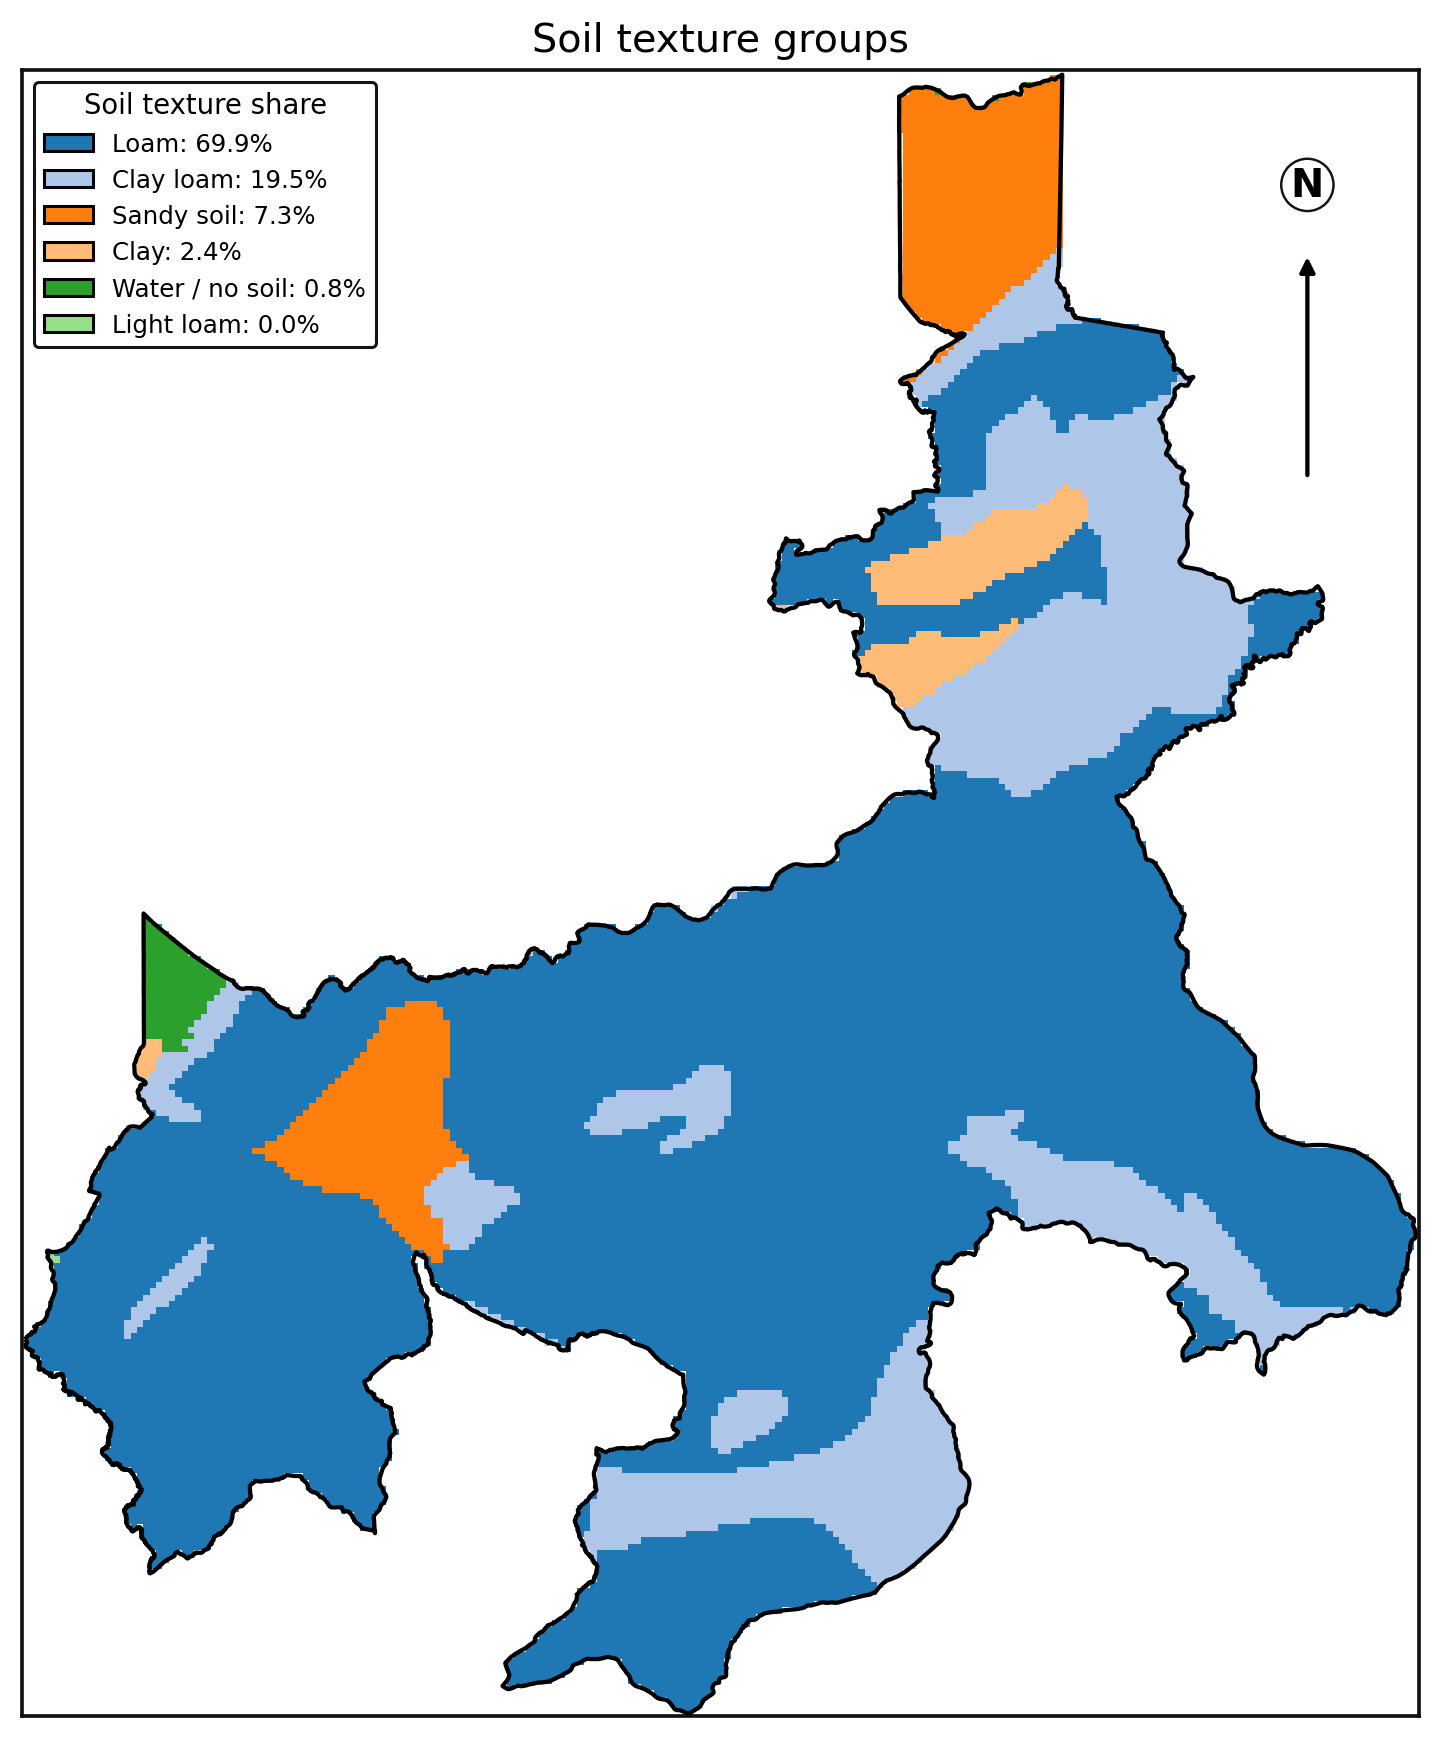

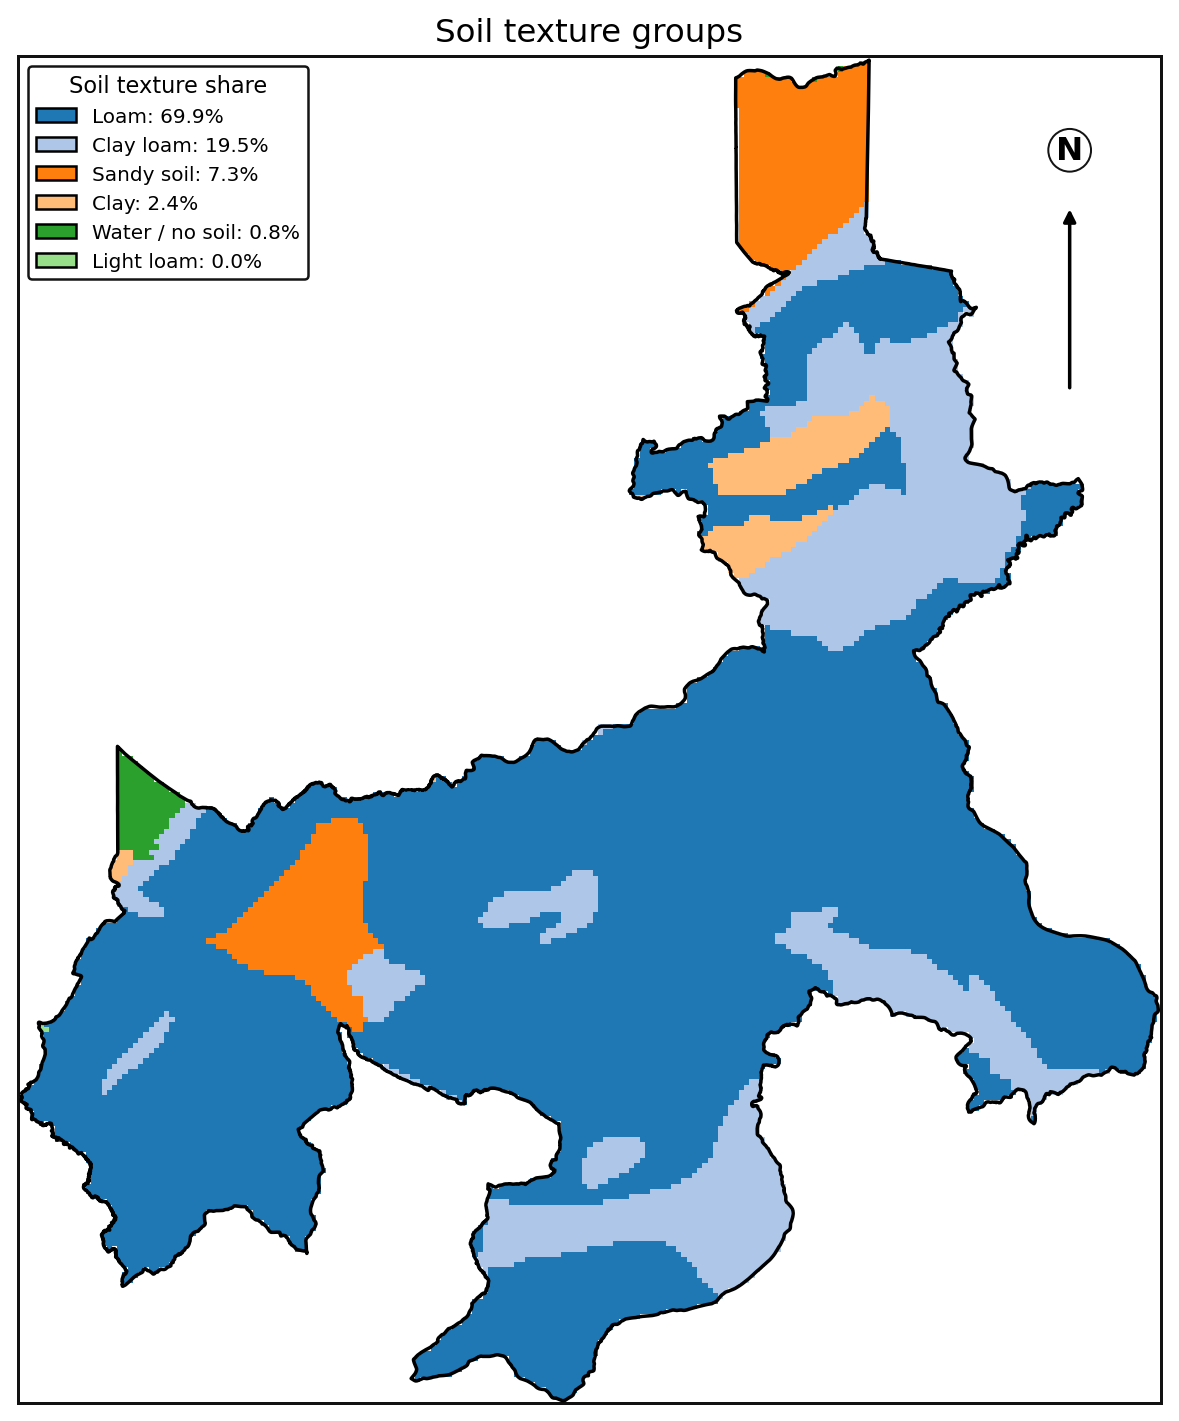

In [14]:
if plt is None:
    print("matplotlib is unavailable; soil map skipped.")
else:
    fig, ax = plt.subplots(figsize=(9, 8), dpi=180)
    draw_soil_base(ax, "Soil texture groups")
    ax.legend(
        handles=soil_legend_handles,
        title="Soil texture share",
        loc="upper left",
        fontsize=8,
        title_fontsize=9,
        frameon=True,
        facecolor="white",
        edgecolor="black",
        framealpha=0.92,
    )
    save_and_display(fig, AOI_HWSD_SOIL_MAP_PNG)


## Soil Texture Map With Cropland Overlay


Wrote map image: /Users/paullwanga/Programming_projects/enhanced_rock_weathering/erw_spatial_mrv/data/processed/soil/hwsd2/hwsd2_aoi_soil_texture_cropland_overlay_map.png


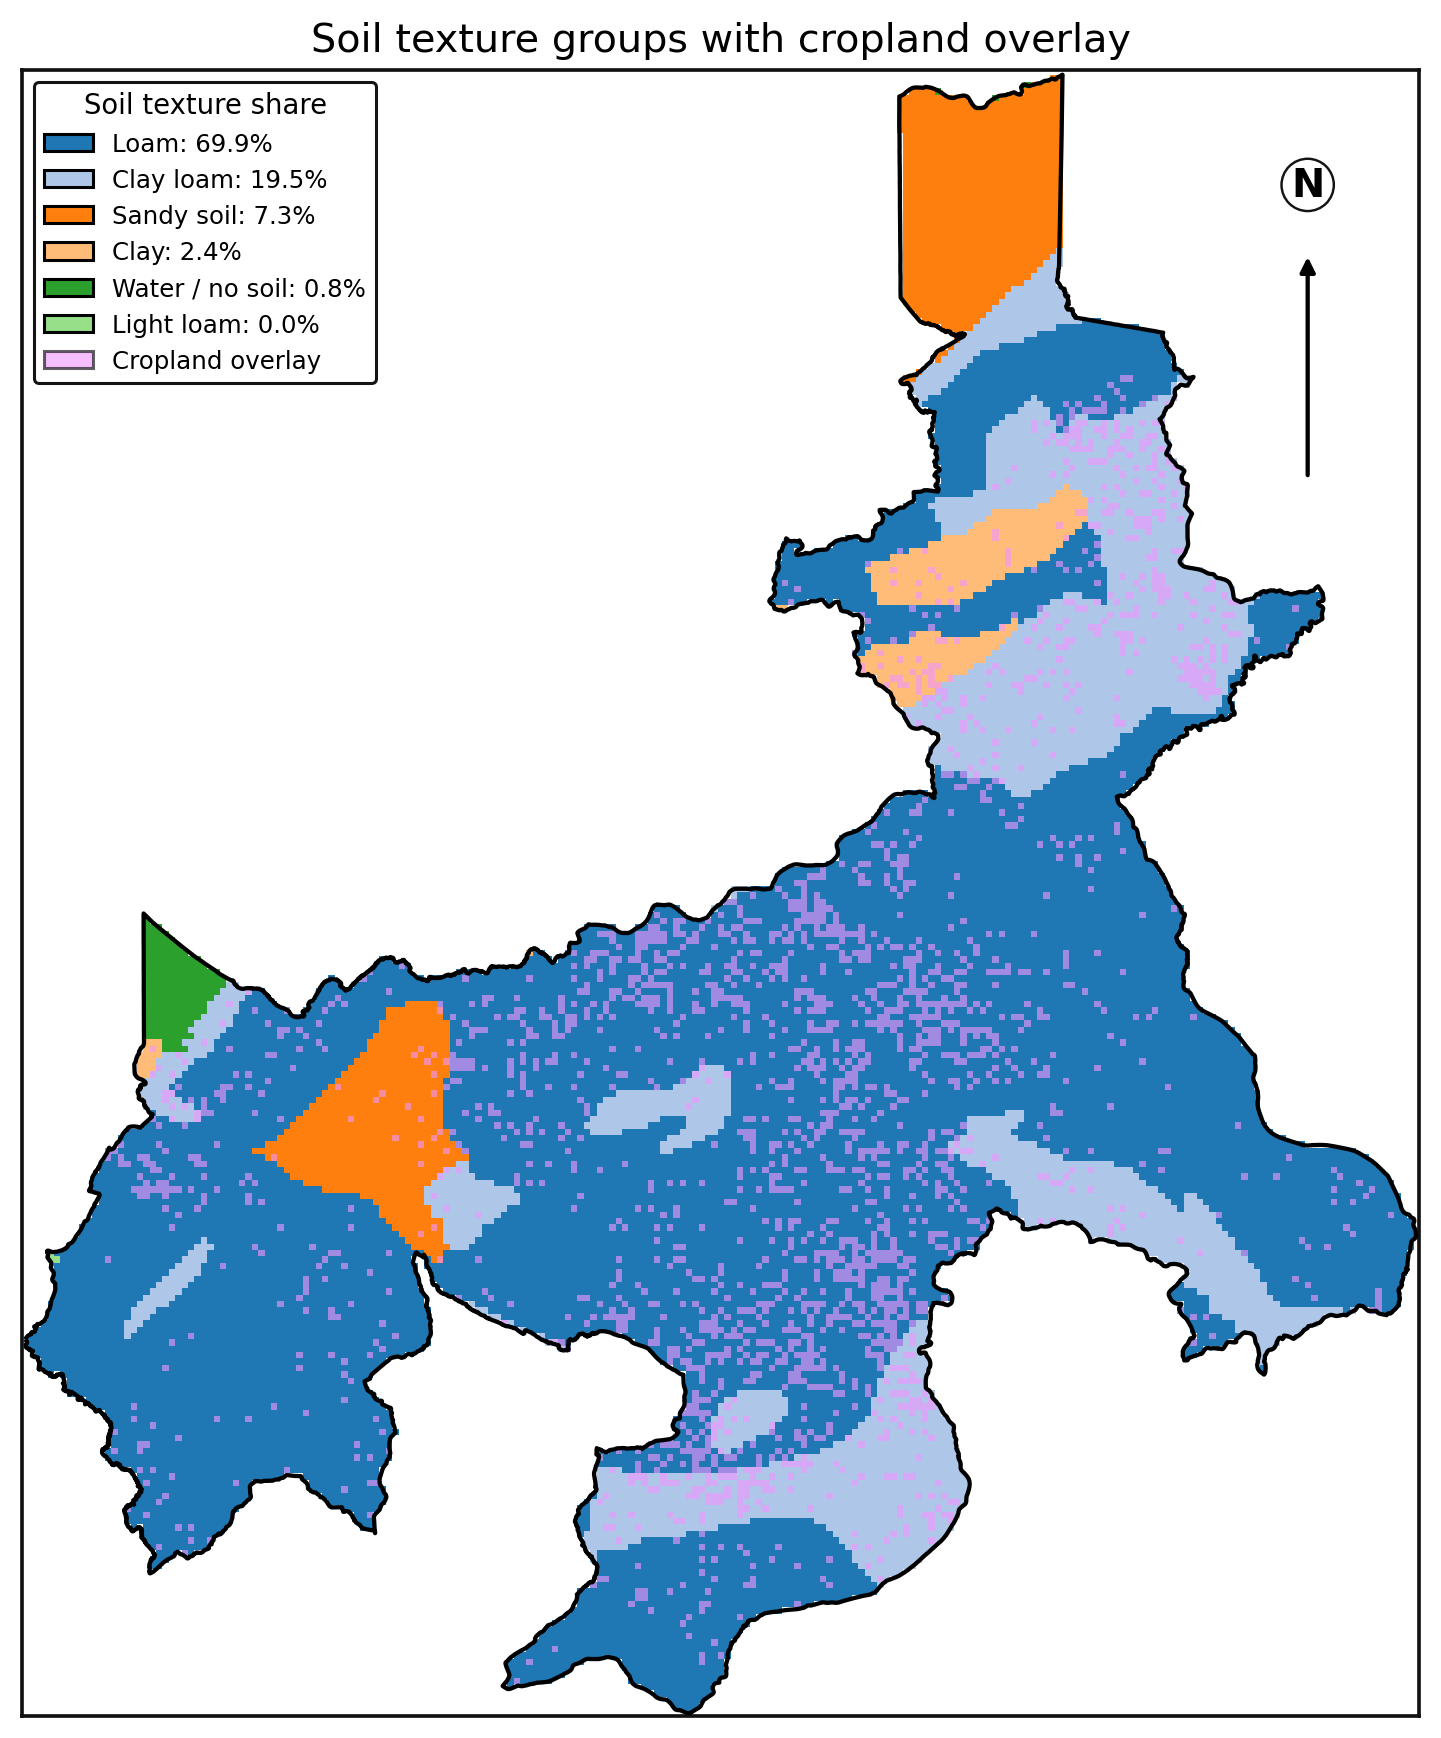

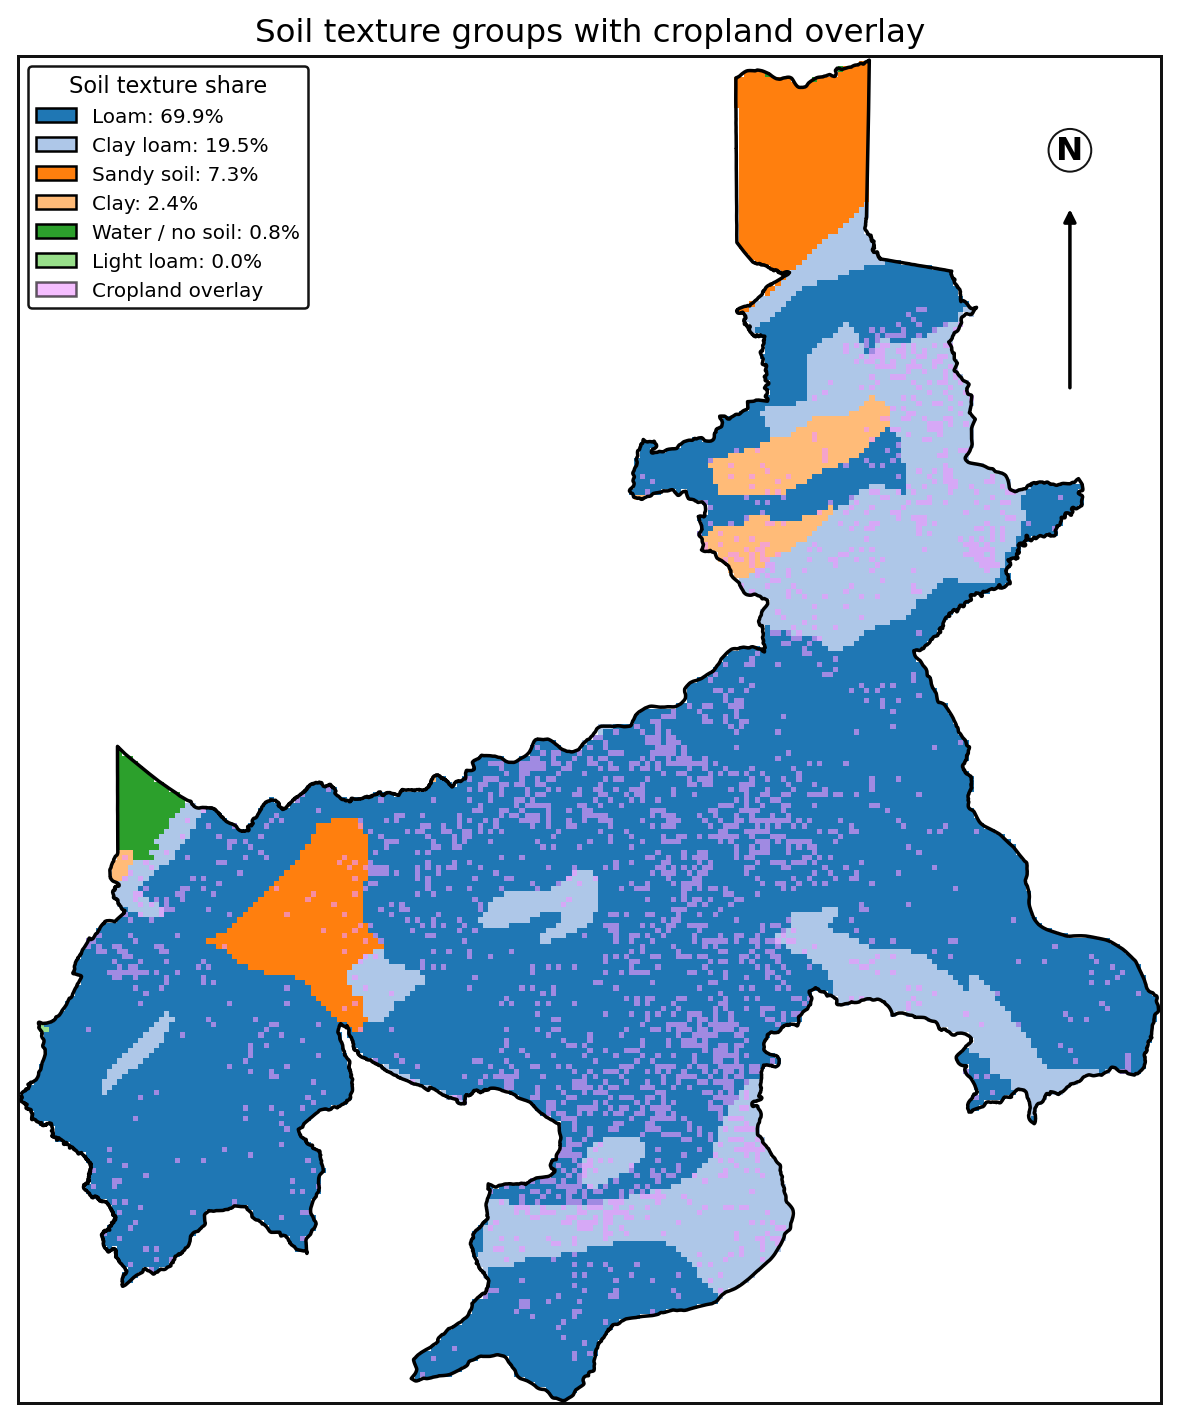

In [15]:
if plt is None:
    print("matplotlib is unavailable; cropland overlay map skipped.")
else:
    cropland_overlay = None
    if CROPLAND_OVERLAY_RASTER is not None:
        cropland_aligned = np.zeros(soil_raster_shape, dtype="uint8")
        with rasterio.open(CROPLAND_OVERLAY_RASTER) as crop_src:
            reproject(
                source=rasterio.band(crop_src, 1),
                destination=cropland_aligned,
                src_transform=crop_src.transform,
                src_crs=crop_src.crs,
                src_nodata=crop_src.nodata,
                dst_transform=soil_raster_transform,
                dst_crs=soil_raster_crs,
                dst_nodata=0,
                resampling=Resampling.nearest,
            )
        cropland_overlay = np.ma.masked_where(cropland_aligned <= 0, cropland_aligned)

    fig, ax = plt.subplots(figsize=(9, 8), dpi=180)
    draw_soil_base(ax, "Soil texture groups with cropland overlay")

    legend_handles = list(soil_legend_handles)
    if cropland_overlay is not None and cropland_overlay.count() > 0:
        ax.imshow(
            cropland_overlay,
            cmap=ListedColormap(["#f096ff"]),
            extent=(soil_bounds.left, soil_bounds.right, soil_bounds.bottom, soil_bounds.top),
            origin="upper",
            alpha=0.62,
            zorder=4,
        )
        legend_handles.append(Patch(facecolor="#f096ff", edgecolor="black", alpha=0.62, label="Cropland overlay"))
    else:
        print("No cropland overlay raster found or no cropland pixels intersect the soil map.")

    ax.legend(
        handles=legend_handles,
        title="Soil texture share",
        loc="upper left",
        fontsize=8,
        title_fontsize=9,
        frameon=True,
        facecolor="white",
        edgecolor="black",
        framealpha=0.92,
    )
    save_and_display(fig, AOI_HWSD_CROPLAND_OVERLAY_MAP_PNG)


## Outputs From This Notebook

This notebook writes under `data/processed/soil/hwsd2/`:

- `hwsd2_aoi_mapping_units.tif`: HWSD2 mapping-unit raster clipped to the AOI.
- `hwsd2_aoi_soil_texture_map.png`: soil-only AOI texture map with legend and north arrow.
- `hwsd2_aoi_soil_texture_cropland_overlay_map.png`: soil texture map with cropland overlay.
- `hwsd2_aoi_mapping_units.csv`: mapping-unit IDs and pixel shares inside the AOI.
- `hwsd2_aoi_soil_properties.csv`: mapping-unit summary joined to HWSD2 attributes when available.
- `hwsd2_aoi_soil_types.gpkg`: AOI soil-type polygons joined to HWSD2 attributes.
- `hwsd2_aoi_soil_types.geojson`: the same AOI soil-type layer for quick web/GIS preview.
- `scepter_soil_defaults_hwsd2.csv`: AOI-weighted soil defaults for SCEPTER when pH/CEC/clay/bulk-density columns are available.

The raster value is joined to the HWSD2 mapping-unit key from the MDB/table. If the auto-selected MDB table is not the mapping-unit attribute table, set `MDB_TABLE_NAME` explicitly and rerun from the attribute-table cells.
